# chap 6

목차
1. 데이터와 기준 모델
2. XGBoost 하이퍼파라미터
3. 조기 종료
4. 하이퍼파라미터 결합
5. 하이퍼파라미터 조정

## 1. 데이터와 기준 모델

데이터와 베이스라인 모델을 만들어보자

In [5]:
# 데이터 로딩
import pandas as pd
from pathlib import Path
file_dir = Path.cwd().parents[2] / "04_Resources" / "Dataset" / "XGBoost"

df = pd.read_csv(file_dir/"heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
# 기본 정보
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
y = df['target']
X = df.drop('target', axis=1)

model = XGBClassifier(booster='gbtree', objective='binary:logistic') # 기본값이지만 공부를 위해 명시적으로 적음

In [14]:
from sklearn.model_selection import cross_val_score
import numpy as np
scores = cross_val_score(model, X, y, cv=5)
print(f"scores: {np.round(scores, 3)}")
print(f"scores mean: {np.mean(scores):.3f}")

scores: [0.82  0.803 0.77  0.783 0.767]
scores mean: 0.789


### StratifiedKFold

하이퍼파라미터 튜닝을 할 때 GridSearchCV나 RandomizedSearchCV가 기본적이다. 분류 모델에서 폴드 별 타깃 레이블의 비율을 일정하게 유지하는 방법을 알아보자

실무 및 캐글 문제를 풀 때는 밑의 코드처럼 명시적으로 shuffle을 해주는게 좋다

In [18]:
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # KFold 객체 생성

In [19]:
scores = cross_val_score(model, X, y, cv=kfold)
print(f"scores: {np.round(scores, 3)}")
print(f"scores mean: {np.mean(scores):.3f}")

scores: [0.82  0.754 0.738 0.817 0.8  ]
scores mean: 0.786


### GridSearch, RandomizedSearchCV

In [29]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def grid_search(params, random=False):
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    xgb = XGBClassifier(booster='gbtree', objective='binary:logistic',
                        random_state=2)
    if random:
        grid = RandomizedSearchCV(xgb, params, cv=kfold, n_iter=20,
                                  n_jobs=-1, random_state=2)
    else:
        grid = GridSearchCV(xgb, params, cv=kfold, n_jobs=-1)
    grid.fit(X, y)
    best_params = grid.best_params_
    best_score = grid.best_score_
    print(f'best params: {best_params}')
    print(f'best score: {best_score}')

## 2. XGBoost 하이퍼파라미터

### n_estimators

앙상블 트리의 개수. 기본값 100부터 늘려가면서 학습해보자

In [24]:
grid_search(params={'n_estimators':[100, 200, 400, 800]})

best params: {'n_estimators': 400}
best params: 0.7954098360655737


### learning_rate

부스팅 각 단계에서 트리의 기여도 조정

In [25]:
grid_search(params={'learning_rate':[0,0.01,0.1,0.5,1,2]})

best params: {'learning_rate': 0.5}
best params: 0.7955737704918033


### max_depth

트리의 깊이 제한 -> 과적합을 방지한다. 기본값은 6이다

In [32]:
grid_search(params={'max_depth':[2,3,5,6,8]})

best params: {'max_depth': 3}
best score: 0.8119672131147541


### gamma

라그랑주 승수(규제항의 $\gamma$). 노드 분할을 위한 최소 손실 감소. 기본 0이며 10 이상은 높다. 높일수록 보수적인 모델 생성.

In [31]:
grid_search(params={'gamma':[0,0.01,0.1,0.5,1,2]})

best params: {'gamma': 0.1}
best score: 0.8119672131147541


### min_child_weight

노드를 분할하기 위해 필요한 최소 가중치 합 지정

In [30]:
grid_search(params={'min_child_weight':[1,2,3,4,5]})

best params: {'min_child_weight': 4}
best score: 0.8119672131147541


### subsample

각 부스팅에서 사용되는 훈련 샘플의 비율 제함. 1에서 줄일수록 과적합 방지

In [33]:
grid_search(params={'subsample':[0.5,0.7,0.8,0.9,1]})

best params: {'subsample': 0.9}
best score: 0.8086885245901639


### colsample_bytree

각 부스팅에서 사용할 특성의 비율 제한.

In [34]:
grid_search(params={'colsample_bytree':[0.5,0.7,0.8,0.9,1]})

best params: {'colsample_bytree': 0.9}
best score: 0.8021857923497269


## 3. 조기 종료

eval_set, eval_metric, early_stopping_rounds 매개변수를 이용함

### eval_set, eval_metric

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, stratify=y)
model = XGBClassifier(eval_metric='error') # 회귀는 보통 rmse
model.fit(X_train, y_train, verbose=True,eval_set = [(X_test, y_test)])
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {accuracy*100}%")

[0]	validation_0-error:0.23684
[1]	validation_0-error:0.23684


[2]	validation_0-error:0.23684
[3]	validation_0-error:0.21053
[4]	validation_0-error:0.19737
[5]	validation_0-error:0.18421
[6]	validation_0-error:0.18421
[7]	validation_0-error:0.18421
[8]	validation_0-error:0.19737
[9]	validation_0-error:0.19737
[10]	validation_0-error:0.19737
[11]	validation_0-error:0.19737
[12]	validation_0-error:0.18421
[13]	validation_0-error:0.19737
[14]	validation_0-error:0.18421
[15]	validation_0-error:0.18421
[16]	validation_0-error:0.18421
[17]	validation_0-error:0.18421
[18]	validation_0-error:0.18421
[19]	validation_0-error:0.18421
[20]	validation_0-error:0.17105
[21]	validation_0-error:0.17105
[22]	validation_0-error:0.17105
[23]	validation_0-error:0.18421
[24]	validation_0-error:0.18421
[25]	validation_0-error:0.18421
[26]	validation_0-error:0.19737
[27]	validation_0-error:0.18421
[28]	validation_0-error:0.18421
[29]	validation_0-error:0.18421
[30]	validation_0-error:0.18421
[31]	validation_0-error:0.18421
[32]	validation_0-error:0.19737
[33]	validation_

### early_stopping_rounds

In [61]:
model = XGBClassifier(eval_metric='error', early_stopping_rounds=100, n_estimators=5000)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {accuracy*100}%")

accuracy: 82.89473684210526%


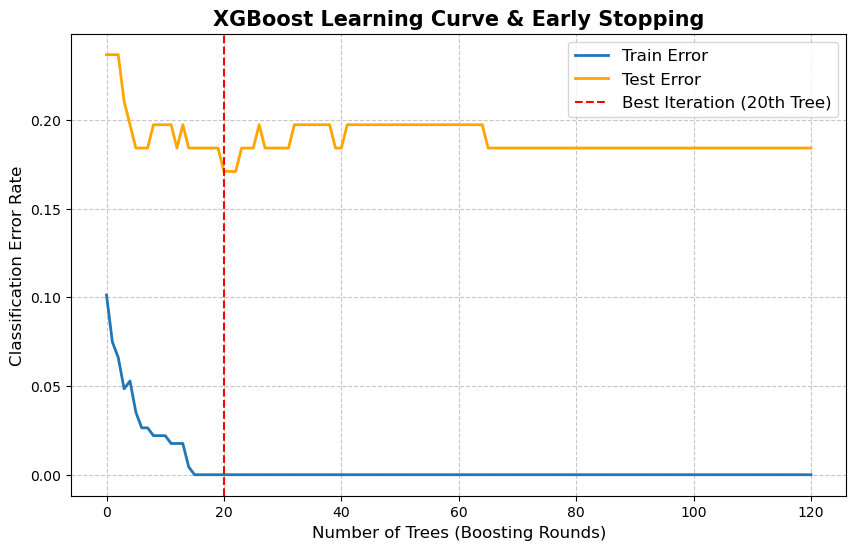

In [62]:
results = model.evals_result()
epochs = len(results['validation_0']['error'])
import matplotlib.pyplot as plt
x_axis=range(0,epochs)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis, results['validation_0']['error'], label='Train Error', linewidth=2)
ax.plot(x_axis, results['validation_1']['error'], label='Test Error', linewidth=2, color='orange')

best_iteration = model.best_iteration
plt.axvline(x=best_iteration, color='red', linestyle='--', 
            label=f'Best Iteration ({best_iteration}th Tree)')

# 그래프 예쁘게 꾸미기
ax.legend(fontsize=12)
plt.xlabel('Number of Trees (Boosting Rounds)', fontsize=12)
plt.ylabel('Classification Error Rate', fontsize=12)
plt.title('XGBoost Learning Curve & Early Stopping', fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## 4. 하이퍼파라미터 결합

In [65]:
grid_search(params={'max_depth':[1,2,3,4,5,6,7],
                    'n_estimators':[50]})

best params: {'max_depth': 1, 'n_estimators': 50}
best score: 0.8547540983606557


In [67]:
grid_search(params={'max_depth':[1,2,3,4,5,6,7],
                    'n_estimators':[2, 5, 20, 50]})

best params: {'max_depth': 1, 'n_estimators': 50}
best score: 0.8547540983606557


In [69]:
grid_search(params={'max_depth':[1],
                    'n_estimators':[50],
                    'learning_rate':[0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]}) # 0.3 기본값

best params: {'learning_rate': 0.3, 'max_depth': 1, 'n_estimators': 50}
best score: 0.8547540983606557


In [70]:
grid_search({'min_child_weight':[1,2,3,4,5],
             'max_depth':[1],
             'n_estimators':[50]})

best params: {'max_depth': 1, 'min_child_weight': 1, 'n_estimators': 50}
best score: 0.8547540983606557


In [78]:
grid_search(params={'min_child_weight':[1,2,3,4,5],
             'subsample':[0.5, 0.6, 0.7, 0.8, 0.9, 1],
             'max_depth':[1,2,3,4,5],
             'n_estimators':[20, 50, 70, 100],
             'learning_rate':[0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]}, random=True)

best params: {'subsample': 0.9, 'n_estimators': 20, 'min_child_weight': 5, 'max_depth': 1, 'learning_rate': 0.5}
best score: 0.8383060109289617


In [80]:
grid_search(params={'colsample_bytree':[0.5,0.6,0.7,0.8,0.9,1],
                    'colsample_bylevel':[0.5,0.6,0.7,0.8,0.9,1],
                    'colsample_bynode':[0.5,0.6,0.7,0.8,0.9,1],
                    'max_depth':[1], 'n_estimators':[50]})

best params: {'colsample_bylevel': 0.5, 'colsample_bynode': 1, 'colsample_bytree': 0.8, 'max_depth': 1, 'n_estimators': 50}
best score: 0.858087431693989


colsample 삼형제. 이 세 가지 파라미터는 독립적으로 작용하는게 아니라 누적해서 작동하므로 너무 낮게 쓰면 과소적합!

따라서 colsample_bytree 하나만 0.6 ~ 0.9 사이로 조절  OR   조금 더 디테일하게 잡고 싶을 때만 bytree와 bynode 두 가지만 조합

In [81]:
grid_search(params={'colsample_bytree':[0.8],
                    'colsample_bylevel':[0.5],
                    'colsample_bynode':[1],
                    'max_depth':[1], 'n_estimators':[50],
                    'gamma':[0, 0.01, 0.05, 0.1, 0.5, 1, 2, 3]})

best params: {'colsample_bylevel': 0.5, 'colsample_bynode': 1, 'colsample_bytree': 0.8, 'gamma': 0, 'max_depth': 1, 'n_estimators': 50}
best score: 0.858087431693989
